In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [7]:
file_path = "C:\\Users\\ASUS\\Desktop\\House Price Prediction Model\\data.csv"
df = pd.read_csv("C:\\Users\\ASUS\\Desktop\\House Price Prediction Model\\data.csv")

In [9]:
print (df.head())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [10]:
print('Dataset Shape:', df.shape)
print('\nColumns:\n', df.columns)

print('\nData Types:\n')
print(df.dtypes)

print('\nMissing Values:\n')
print(df.isnull().sum())

Dataset Shape: (4600, 18)

Columns:
 Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

Data Types:

date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object

Missing Values:

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above  

In [11]:
#EDA

In [12]:
print(df.describe())

              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   862.168977   
min       

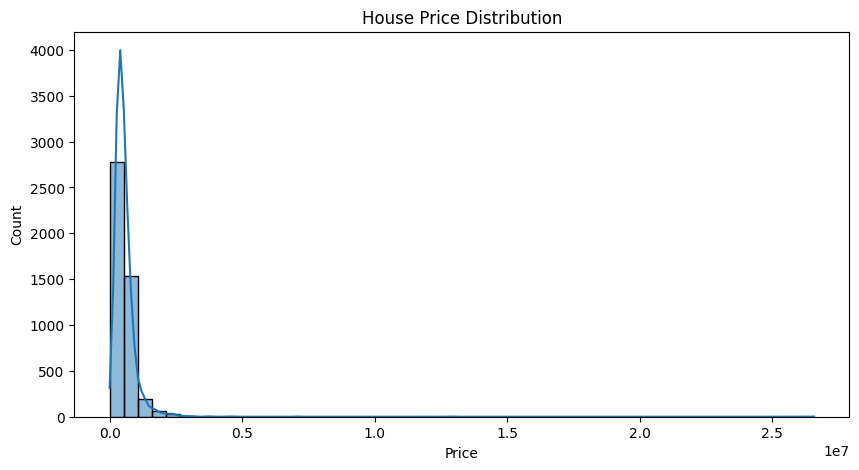

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.show()

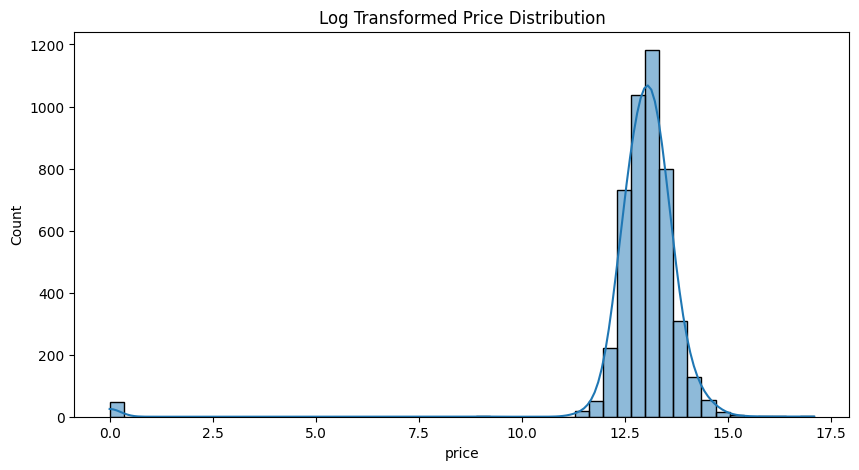

In [14]:
df['price'] = np.log1p(df['price'])

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Log Transformed Price Distribution')
plt.show()

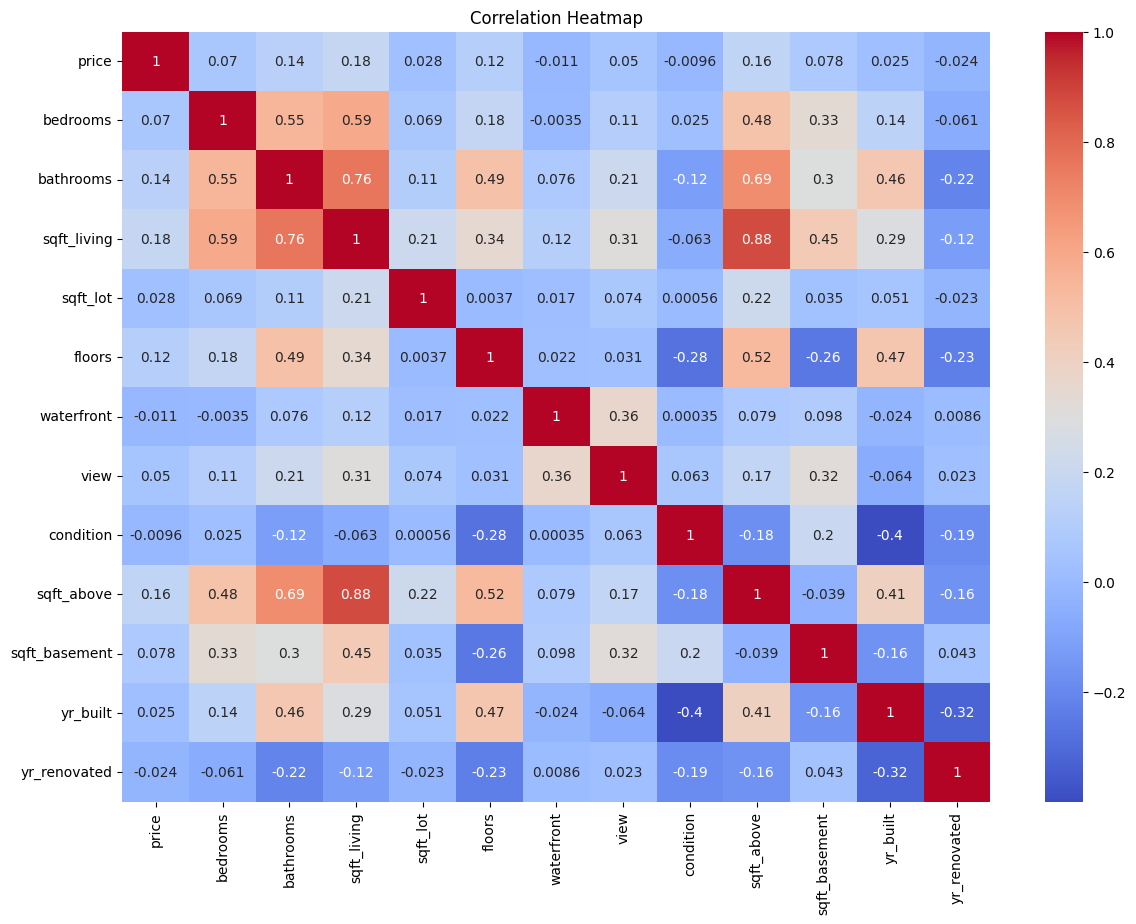

In [15]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
#Feature engineering

In [17]:
df['date'] = pd.to_datetime(df['date'])



df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day



df.drop('date', axis=1, inplace=True)

In [18]:
# Age of the house

df['house_age'] = 2026 - df['yr_built']

# Renovation age

df['renovation_age'] = np.where(
    df['yr_renovated'] == 0,
    0,
    2026 - df['yr_renovated']
)

In [19]:
# Street has extremely high cardinality
# Removing because it may introduce noise

df.drop('street', axis=1, inplace=True)

In [20]:
X = df.drop('price', axis=1)
y = df['price']

In [21]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical Columns:', categorical_cols)
print('Numerical Columns:', numerical_cols)

Categorical Columns: ['city', 'statezip', 'country']
Numerical Columns: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'year', 'month', 'day', 'house_age', 'renovation_age']


In [22]:
#preprocessing

In [23]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Training Shape:', X_train.shape)
print('Testing Shape:', X_test.shape)

Training Shape: (3680, 20)
Testing Shape: (920, 20)


In [25]:
#Model training

In [26]:
results = {}


def evaluate_model(name, model):
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    }
    print(f'\n{name}')
    print('-' * 40)
    print('RMSE:', rmse)
    print('MAE :', mae)
    print('R2  :', r2)

    return pipeline, y_pred

In [28]:
#linear reg
lr_pipeline, lr_pred = evaluate_model(
    'Linear Regression',
    LinearRegression()
)


Linear Regression
----------------------------------------
RMSE: 1.3906941588608128
MAE : 0.43058800919412893
R2  : 0.013324405397649342


In [29]:
#Random Forest Regressor
rf_pipeline, rf_pred = evaluate_model(
    'Random Forest',
    RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
)


Random Forest
----------------------------------------
RMSE: 1.4813359908326384
MAE : 0.466465963040091
R2  : -0.11948498833460275


In [30]:
#gradient regressor
gb_pipeline, gb_pred = evaluate_model(
    'Gradient Boosting',
    GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
)


Gradient Boosting
----------------------------------------
RMSE: 1.5563890255821056
MAE : 0.4782763896647307
R2  : -0.2357978766025166


In [31]:
#compare model
results_df = pd.DataFrame(results).T
print(results_df)

                       RMSE       MAE  R2 Score
Linear Regression  1.390694  0.430588  0.013324
Random Forest      1.481336  0.466466 -0.119485
Gradient Boosting  1.556389  0.478276 -0.235798


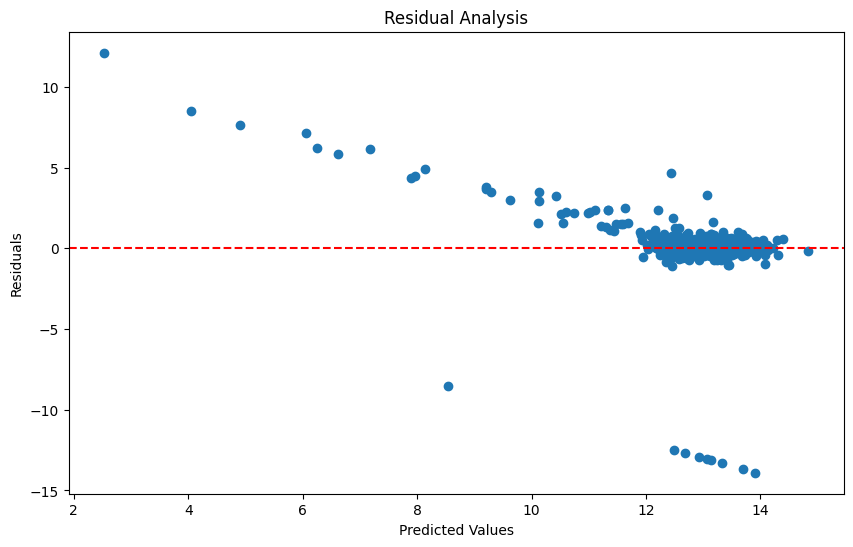

In [32]:
#analysis
best_predictions = gb_pred
residuals = y_test - best_predictions

plt.figure(figsize=(10,6))
plt.scatter(best_predictions, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.show()

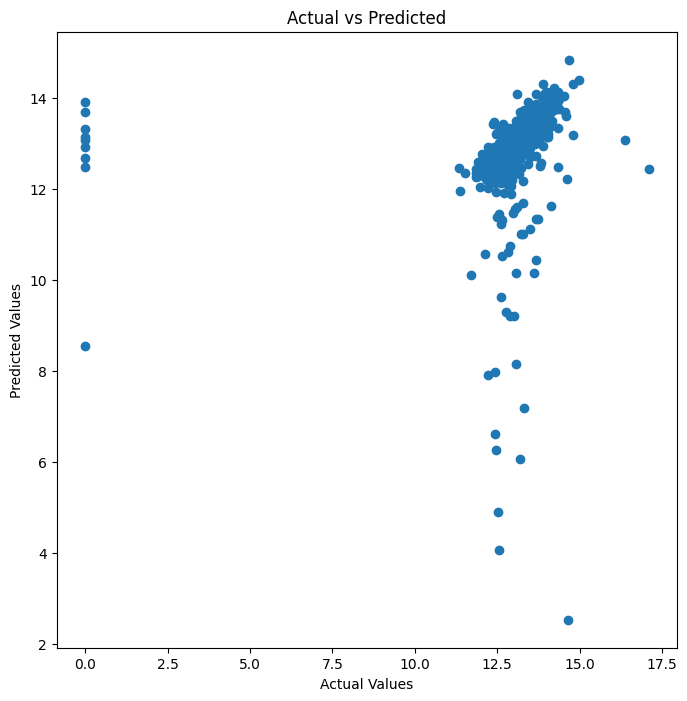

In [33]:
#actual vs predicted
plt.figure(figsize=(8,8))
plt.scatter(y_test, best_predictions)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

In [34]:
# Save Gradient Boosting model
joblib.dump(gb_pipeline, 'house_price_model.pkl')

print('Model saved successfully.')

Model saved successfully.


In [35]:
loaded_model = joblib.load('house_price_model.pkl')

print('Model loaded successfully.')

Model loaded successfully.


In [36]:
#example

In [37]:
sample_data = pd.DataFrame({
    'bedrooms': [3],
    'bathrooms': [2.5],
    'sqft_living': [1800],
    'sqft_lot': [5000],
    'floors': [2],
    'waterfront': [0],
    'view': [0],
    'condition': [4],
    'sqft_above': [1800],
    'sqft_basement': [0],
    'yr_built': [2005],
    'yr_renovated': [0],
    'city': ['Seattle'],
    'statezip': ['WA 98103'],
    'country': ['USA'],
    'year': [2014],
    'month': [5],
    'day': [2],
    'house_age': [21],
    'renovation_age': [0]
})

# Predict log-transformed price
predicted_log_price = loaded_model.predict(sample_data)

# Convert back to original scale
predicted_price = np.expm1(predicted_log_price)

print('Predicted House Price: $', predicted_price[0])

Predicted House Price: $ 552124.0512048334


In [38]:
#git

In [42]:
import os

os.chdir(r"C:\Users\ASUS\Desktop\House Price Prediction Model")

!git init

!git add .

!git commit -m "Initial commit - House Price Prediction Project"

!git remote add origin https://github.com/adeebqureshi/House-Price-Prediction.git

!git branch -M main

!git push -u origin main

Initialized empty Git repository in C:/Users/ASUS/Desktop/House Price Prediction Model/.git/


[master (root-commit) d3c0956] Initial commit - House Price Prediction Project
 4 files changed, 5437 insertions(+)
 create mode 100644 .ipynb_checkpoints/House Price Prediction-checkpoint.ipynb
 create mode 100644 House Price Prediction.ipynb
 create mode 100644 data.csv
 create mode 100644 house_price_model.pkl


To https://github.com/adeebqureshi/House-Price-Prediction.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/adeebqureshi/House-Price-Prediction.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
